MLE:  θ̂ = k/N = 26/40 = 0.6500
Log-likelihood at MLE: ℓ(θ̂) = -2.0301


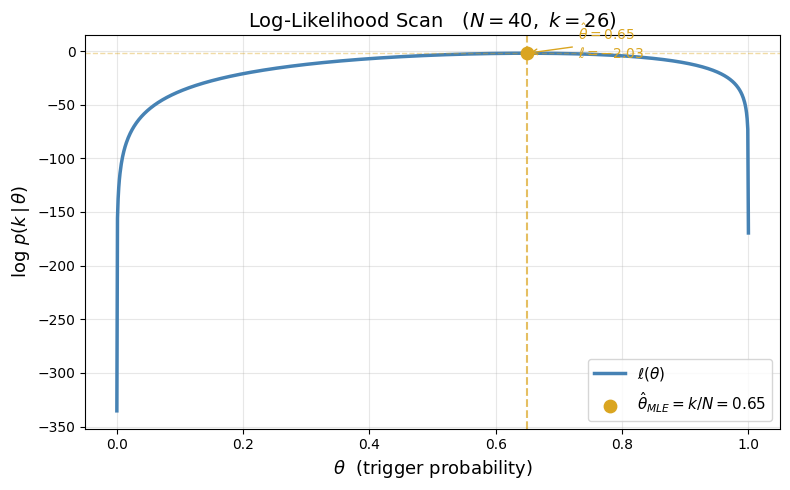

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln  # for log of binomial coefficient

# Parameters
N = 40
k = 26

def log_likelihood(theta, k, N):
    """
    Log-likelihood of observing k successes in N Bernoulli trials.
    log p(k|theta) = log C(N,k) + k*log(theta) + (N-k)*log(1-theta)
    """
    log_binom = gammaln(N + 1) - gammaln(k + 1) - gammaln(N - k + 1)
    return log_binom + k * np.log(theta) + (N - k) * np.log(1 - theta)

theta = np.linspace(1e-6, 1 - 1e-6, 1000)   # avoid log(0)
ll    = log_likelihood(theta, k, N)

# MLE (analytical)
theta_mle = k / N
ll_mle    = log_likelihood(theta_mle, k, N)

print(f"MLE:  θ̂ = k/N = {k}/{N} = {theta_mle:.4f}")
print(f"Log-likelihood at MLE: ℓ(θ̂) = {ll_mle:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(theta, ll, color='steelblue', lw=2.5, label=r'$\ell(\theta)$')

# Mark the maximum
ax.axvline(theta_mle, color='goldenrod', lw=1.5, linestyle='--', alpha=0.7)
ax.axhline(ll_mle,    color='goldenrod', lw=1.0, linestyle='--', alpha=0.4)
ax.scatter([theta_mle], [ll_mle], color='goldenrod', s=80, zorder=5,
           label=rf'$\hat{{\theta}}_{{MLE}} = k/N = {theta_mle:.2f}$')

# Annotations
ax.annotate(
    rf'$\hat{{\theta}} = {theta_mle:.2f}$' + f'\n' + rf'$\ell = {ll_mle:.2f}$',
    xy=(theta_mle, ll_mle),
    xytext=(theta_mle + 0.08, ll_mle - 4),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='goldenrod'),
    color='goldenrod'
)

# Labels
ax.set_xlabel(r'$\theta$  (trigger probability)', fontsize=13)
ax.set_ylabel(r'$\log\, p(k\,|\,\theta)$', fontsize=13)
ax.set_title(rf'Log-Likelihood Scan   ($N={N},\ k={k}$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

θ̂  = 0.6500
lower bound: θ₋ = 0.5726  (−0.0774)
upper bound: θ₊ = 0.7225  (+0.0725)


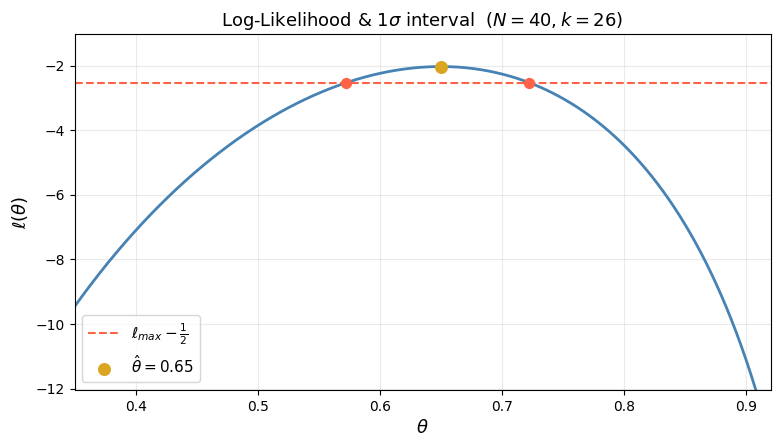

In [11]:
from scipy.optimize import brentq

N, k = 40, 26

def logL(theta):
    log_binom = gammaln(N+1) - gammaln(k+1) - gammaln(N-k+1)
    return log_binom + k*np.log(theta) + (N-k)*np.log(1-theta)

theta     = np.linspace(1e-4, 1-1e-4, 2000)
ll        = logL(theta)
theta_mle = k / N
ll_max    = logL(theta_mle)
threshold = ll_max - 0.5

# Numerical 1σ bounds
f        = lambda t: logL(t) - threshold
theta_lo = brentq(f, 1e-4, theta_mle)
theta_hi = brentq(f, theta_mle, 1-1e-4)

print(f"θ̂  = {theta_mle:.4f}")
print(f"lower bound: θ₋ = {theta_lo:.4f}  (−{theta_mle-theta_lo:.4f})")
print(f"upper bound: θ₊ = {theta_hi:.4f}  (+{theta_hi-theta_mle:.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(theta, ll, 'steelblue', lw=2)
ax.axhline(threshold, color='tomato', ls='--', lw=1.5, label=r'$\ell_{max} - \frac{1}{2}$')

ax.scatter([theta_mle], [ll_max], color='goldenrod', zorder=5, s=70,
           label=rf'$\hat{{\theta}}={theta_mle:.2f}$')
ax.scatter([theta_lo, theta_hi], [threshold, threshold], color='tomato', zorder=5, s=50)

ax.set_xlim(0.35, 0.92)
ax.set_ylim(ll_max - 10, ll_max + 1)
ax.set_xlabel(r'$\theta$', fontsize=13)
ax.set_ylabel(r'$\ell(\theta)$', fontsize=13)
ax.set_title(rf'Log-Likelihood & $1\sigma$ interval  ($N={N}, k={k}$)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)

plt.subplots_adjust(bottom=0.13, top=0.92, left=0.1, right=0.97)
plt.show()

## Why the Likelihood Peak Width Represents Parameter Uncertainty

The likelihood $\mathcal{L}(\theta)$ tells you how well each value of $\theta$ explains the data.

- A **sharp peak** means the data strongly prefer one particular $\theta$ and rule out nearby values quickly — **small uncertainty**
- A **broad peak** means many values of $\theta$ fit the data almost equally well — **large uncertainty**

The threshold $\ell_\max - \tfrac{1}{2}$ formalizes this: it asks how far you can move from $\hat\theta$ before the fit degrades meaningfully. That distance is your $1\sigma$ uncertainty.

> **Key insight: curvature = information.**
> High curvature (narrow peak) → data are informative about $\theta$.
> Low curvature (flat peak) → data are not.

This is directly related to the **Fisher information**:

$$\mathcal{I}(\theta) = -\left\langle \frac{d^2 \ell}{d\theta^2} \right\rangle \quad \Rightarrow \quad \sigma \approx \frac{1}{\sqrt{\mathcal{I}(\hat\theta)}}$$

A sharper peak (larger $|\ell''|$) means more Fisher information and a smaller uncertainty.